In [140]:
import pandas as pd
import numpy as np

In [141]:
train = pd.read_csv('/content/True.csv')
train.sample(10)

,title,text,subject,date
19198,"Not so fast, Theresa: EU seeks divorce terms t...",BRUSSELS (Reuters) - In pledging to stay best ...,worldnews,"September 24, 2017"
13066,U.S. consulate in Jerusalem issues security me...,JERUSALEM (Reuters) - The U.S. Consulate in Je...,worldnews,"December 5, 2017"
7706,Trump asks team to trim back transition effort...,NEW YORK (Reuters) - Trailing in opinion polls...,politicsNews,"October 25, 2016"
20991,"UK police arrest four, including soldiers, ove...",LONDON (Reuters) - British police arrested fou...,worldnews,"September 5, 2017"
14483,China says will work with North Korea to boost...,BEIJING/SEOUL (Reuters) - Traditional friendsh...,worldnews,"November 17, 2017"
17774,"With far-right in turmoil, France's Le Pen sof...",PARIS (Reuters) - Far-right leader Marine Le P...,worldnews,"October 11, 2017"
15325,UCLA basketball players arrested in China ahea...,SHANGHAI (Reuters) - Three UCLA men s basketba...,worldnews,"November 8, 2017"
7319,Trump may already have a plan ready to revamp ...,"WASHINGTON (Reuters) - When Jeb Hensarling, th...",politicsNews,"November 11, 2016"
14500,"The boss is dead but the mafia lives, magistra...",ROME/PALERMO (Reuters) - The death of Sicilian...,worldnews,"November 17, 2017"
9618,Commentary: Party leaders often disliked their...,GOP leaders have unleashed a stunning level of...,politicsNews,"May 10, 2016"


In [142]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [143]:
train.shape

(21417, 4)

In [144]:
train.isna().sum()

,0
title,0
text,0
subject,0
date,0


In [145]:
train.duplicated().sum()

np.int64(206)

In [146]:
train.drop_duplicates(inplace=True)

In [147]:
train['fake'] = 0

In [148]:
train.head()

,title,text,subject,date,fake
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0


In [149]:
train.dtypes

,0
title,object
text,object
subject,object
date,object
fake,int64


In [150]:
# train['date'] = pd.to_datetime(train['date']) had to drop because test doesn't support this column
train.drop('date', axis=1, inplace=True)

In [151]:
train.dtypes

,0
title,object
text,object
subject,object
fake,int64


In [152]:
test = pd.read_csv('/content/Fake.csv')
test.sample(10)

,title,text,subject,date
5771,House Republicans Turn Off Cameras So America...,This is disgraceful and it is an insult to eve...,News,"June 22, 2016"
6690,Donald Trump Terrorizes His Fans: ‘Lock Your ...,"On Monday, it seemed that Donald Trump has giv...",News,"April 26, 2016"
1361,Trump Organization Brazenly Admits It’s Just ...,"Obeying the law can be such a pain in the ass,...",News,"May 25, 2017"
6442,Mexico’s Former President UNLOADS On Trump Wi...,"Donald Trump has p*ssed off so many people, it...",News,"May 10, 2016"
12142,"COLLEGE That Receives $280 Million In State, F...",OSU will receive more than $212 million in fed...,politics,"Dec 14, 2016"
345,Trump Judicial Nominee: Transgender Children ...,Donald Trump s nominee for a federal judgeship...,News,"September 20, 2017"
23013,The Court Case Against the ‘Travel Ban’ Execut...,21st Century Wire says The legal battle is wag...,Middle-east,"February 6, 2017"
2218,Trump Just Did Something REALLY Weird On Twit...,Donald Trump really doesn t make sticky situat...,News,"March 9, 2017"
22414,Hillary’s Secret Weapon: Evan McMullin is CIA-...,J.R. Smith 21st Century WireMuch has been made...,US_News,"October 31, 2016"
12508,IS THIS WHY HILLARY Has Become “Unhinged”? Per...,,politics,"Nov 4, 2016"


In [153]:
test.columns

Index(['title', 'text', 'subject', 'date'], dtype='object')

In [154]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [155]:
test.isna().sum()

,0
title,0
text,0
subject,0
date,0


In [156]:
test.duplicated().sum()

np.int64(3)

In [157]:
test.drop_duplicates(inplace=True)

In [158]:
test.dtypes

,0
title,object
text,object
subject,object
date,object


In [159]:
test['date'] = test['date'].str.replace('-', ' ')

In [160]:
# test['date'] = pd.to_datetime(test['date'], format="%d %b %Y") soo many inconsistency, no specific format!
test.drop('date', axis=1, inplace=True)
test['fake'] = 1

In [161]:
df = pd.concat([train, test], ignore_index=True) # mergin
df

,title,text,subject,fake
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,0
...,...,...,...,...
44684,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,1
44685,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,1
44686,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,1
44687,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,1


In [162]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True) # suffling
df

,title,text,subject,fake
0,"Merkel, Juncker discuss Catalan crisis: EU off...",BRUSSELS (Reuters) - German Chancellor Angela ...,worldnews,0
1,LIBERAL HACK KATIE COURIC Says Fake News Is “T...,Katie Couric is a wolf in sheep s clothing. Da...,left-news,1
2,TRUMP WAS RIGHT! Audit Reveals State Dept. Cyb...,New documents appear to show a pattern of dete...,politics,1
3,Clay Aiken Says He Was A ‘F*****g Dumbass’ Fo...,Former American Idol finalist and Celebrity...,News,1
4,U.S. militia girds for trouble as presidential...,"JACKSON, Ga. (Reuters) - Down a Georgia count...",politicsNews,0
...,...,...,...,...
44684,Germany's Schaeuble warns Trump over protectio...,BERLIN (Reuters) - German Finance Minister Wol...,politicsNews,0
44685,"Twenty-eight arrests after Venezuela looting, ...","PUERTO ORDAZ, Venezuela (Reuters) - Venezuelan...",worldnews,0
44686,HOW THE FBI Cracked A Terror Plot On Black Fri...,The U.S. is the great enemy of mankind! rave...,Government News,1
44687,U.S. tax plan threatens Wall Street's Bermuda ...,NEW YORK (Reuters) - U.S. money managers with ...,politicsNews,0


In [163]:
df.drop('subject', axis=1, inplace=True) # subject contributes to only 0.36% of accuracy, so removing it to reduce computation tasks

In [164]:
obj_cols = df.select_dtypes(include=['object'])
obj_cols

,title,text
0,"Merkel, Juncker discuss Catalan crisis: EU off...",BRUSSELS (Reuters) - German Chancellor Angela ...
1,LIBERAL HACK KATIE COURIC Says Fake News Is “T...,Katie Couric is a wolf in sheep s clothing. Da...
2,TRUMP WAS RIGHT! Audit Reveals State Dept. Cyb...,New documents appear to show a pattern of dete...
3,Clay Aiken Says He Was A ‘F*****g Dumbass’ Fo...,Former American Idol finalist and Celebrity...
4,U.S. militia girds for trouble as presidential...,"JACKSON, Ga. (Reuters) - Down a Georgia count..."
...,...,...
44684,Germany's Schaeuble warns Trump over protectio...,BERLIN (Reuters) - German Finance Minister Wol...
44685,"Twenty-eight arrests after Venezuela looting, ...","PUERTO ORDAZ, Venezuela (Reuters) - Venezuelan..."
44686,HOW THE FBI Cracked A Terror Plot On Black Fri...,The U.S. is the great enemy of mankind! rave...
44687,U.S. tax plan threatens Wall Street's Bermuda ...,NEW YORK (Reuters) - U.S. money managers with ...


In [165]:
for col in obj_cols:
  df[col] = df[col].str.lower()
  df[col] = df[col].str.strip()
  df[col] = df[col].str.replace(r'[^\w\s]', '', regex=True)
  df[col] = df[col].str.replace(r'\s+', ' ', regex=True)
df

,title,text,fake
0,merkel juncker discuss catalan crisis eu official,brussels reuters german chancellor angela merk...,0
1,liberal hack katie couric says fake news is te...,katie couric is a wolf in sheep s clothing dan...,1
2,trump was right audit reveals state dept cyber...,new documents appear to show a pattern of dete...,1
3,clay aiken says he was a fg dumbass for thinki...,former american idol finalist and celebrity ap...,1
4,us militia girds for trouble as presidential e...,jackson ga reuters down a georgia country road...,0
...,...,...,...
44684,germanys schaeuble warns trump over protection...,berlin reuters german finance minister wolfgan...,0
44685,twentyeight arrests after venezuela looting vi...,puerto ordaz venezuela reuters venezuelan auth...,0
44686,how the fbi cracked a terror plot on black fri...,the us is the great enemy of mankind raved ern...,1
44687,us tax plan threatens wall streets bermuda idyll,new york reuters us money managers with reinsu...,0


In [166]:
from nltk.corpus import stopwords

def removeStopWords(text):
  stopword = set(stopwords.words('english'))
  words = text.split()
  filtered_words = [word for word in words if word not in stopword]
  return ' '.join(filtered_words)

In [167]:
for col in obj_cols:
  df[col] = df[col].apply(removeStopWords)
df

,title,text,fake
0,merkel juncker discuss catalan crisis eu official,brussels reuters german chancellor angela merk...,0
1,liberal hack katie couric says fake news teari...,katie couric wolf sheep clothing dan rather br...,1
2,trump right audit reveals state dept cybersecu...,new documents appear show pattern deterioratio...,1
3,clay aiken says fg dumbass thinking trump wasn...,former american idol finalist celebrity appren...,1
4,us militia girds trouble presidential election...,jackson ga reuters georgia country road camouf...,0
...,...,...,...
44684,germanys schaeuble warns trump protectionism wsj,berlin reuters german finance minister wolfgan...,0
44685,twentyeight arrests venezuela looting violence,puerto ordaz venezuela reuters venezuelan auth...,0
44686,fbi cracked terror plot black friday may worse...,us great enemy mankind raved ernesto che gueva...,1
44687,us tax plan threatens wall streets bermuda idyll,new york reuters us money managers reinsurance...,0


In [168]:
df.shape

(44689, 3)

In [169]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stem_words(text):
    return " ".join(stemmer.stem(word) for word in text.split())

In [170]:
df

,title,text,fake
0,merkel juncker discuss catalan crisis eu official,brussels reuters german chancellor angela merk...,0
1,liberal hack katie couric says fake news teari...,katie couric wolf sheep clothing dan rather br...,1
2,trump right audit reveals state dept cybersecu...,new documents appear show pattern deterioratio...,1
3,clay aiken says fg dumbass thinking trump wasn...,former american idol finalist celebrity appren...,1
4,us militia girds trouble presidential election...,jackson ga reuters georgia country road camouf...,0
...,...,...,...
44684,germanys schaeuble warns trump protectionism wsj,berlin reuters german finance minister wolfgan...,0
44685,twentyeight arrests venezuela looting violence,puerto ordaz venezuela reuters venezuelan auth...,0
44686,fbi cracked terror plot black friday may worse...,us great enemy mankind raved ernesto che gueva...,1
44687,us tax plan threatens wall streets bermuda idyll,new york reuters us money managers reinsurance...,0


In [172]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

df['content'] = df['text'] + ' ' + df['title']
X_train, X_test, y_train, y_test = train_test_split(df["content"],df["fake"],test_size=0.2,random_state=42,stratify=df["fake"])

tfidf = TfidfVectorizer()
X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [173]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9872454687849631
[[4193   49]
 [  65 4631]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4242
           1       0.99      0.99      0.99      4696

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



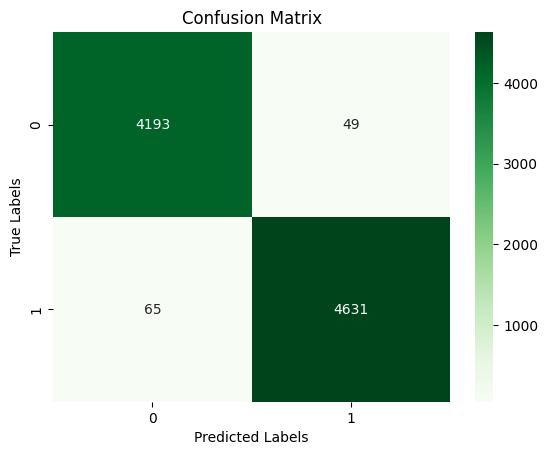

In [174]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Greens")
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [186]:
print(df["fake"].value_counts())

fake
1    23478
0    21211
Name: count, dtype: int64


In [175]:
df.to_csv('modifieddata.csv', index=False)

In [181]:
# Random fake + real samples from your dataset
test_df = pd.concat([
    df[df["fake"] == 0].sample(5, random_state=42),
    df[df["fake"] == 1].sample(5, random_state=42)
])

test_df = test_df[["text", "fake"]].reset_index(drop=True)

test_df

,text,fake
0,dubai reuters saudi arabia aims start issuing ...,0
1,amman reuters military jets believed russian k...,0
2,washington reuters fbi secured court order 201...,0
3,kuala lumpur reuters eleven foreign workers ki...,0
4,londonbrussels reuters britain european union ...,0
5,one america legendary journalists dan rather u...,1
6,every union member believes democrats looking ...,1
7,terrified concert goers fled ariana grande gig...,1
8,day one donald trump failure presidency perfec...,1
9,donald trump disgraced united states made coun...,1


In [184]:
news_df["text"] = news_df["text"].str.lower()
news_df["text"] = news_df["text"].str.replace(r"[^\w\s]", "", regex=True)
news_df["text"] = news_df["text"].str.replace(r"\s+", " ", regex=True).str.strip()
news_df["text"] = news_df["text"].apply(removeStopWords)
news_df["text"] = news_df["text"].apply(stemWords)
X_news = tfidf.transform(news_df["text"])
predictions = model.predict(X_news)

test_df["prediction"] = model.predict(tfidf.transform(test_df["text"]))

test_df[["fake", "prediction"]]

,fake,prediction
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,1,1
6,1,1
7,1,1
8,1,1
9,1,1


In [180]:
print(model.classes_)
print(predictions)
print(df["fake"].value_counts())

[0 1]
[1 1 1 1 1 1 1 1 1 1]
fake
1    23478
0    21211
Name: count, dtype: int64


In [183]:
test_df.head()

,text,fake
0,dubai reuters saudi arabia aims start issuing ...,0
1,amman reuters military jets believed russian k...,0
2,washington reuters fbi secured court order 201...,0
3,kuala lumpur reuters eleven foreign workers ki...,0
4,londonbrussels reuters britain european union ...,0


In [185]:
import joblib

joblib.dump(model, "fake_news_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']